<a href="https://www.kaggle.com/code/lalit7881/icu-mortality-prediction?scriptVersionId=301919095" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jayjoshi37/icu-patient-monitoring-and-mortality-prediction/ICU_Patient_Monitoring_Mortality_Prediction_15000.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jayjoshi37/icu-patient-monitoring-and-mortality-prediction/ICU_Patient_Monitoring_Mortality_Prediction_15000.csv")

In [3]:
df.head()

,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1
3,PAT000004,21,Male,Emergency,1.96,63.62,11.51,82.22,51.84,164.59,...,214.40,1.06,4940.99,1,0,1.16,33.54,14.14,0,1
4,PAT000005,21,Male,Urgent,7.71,65.92,12.17,74.98,39.34,146.10,...,201.33,5.28,4492.46,0,0,21.68,31.63,11.23,0,0


In [4]:
df.tail()

,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
14995,PAT014996,27,Female,Elective,0.02,100.21,15.97,105.34,79.25,123.65,...,217.13,3.22,1034.24,1,0,13.41,13.89,8.30,0,0
14996,PAT014997,68,Male,Emergency,8.39,88.72,13.34,100.69,77.45,148.53,...,171.81,5.17,989.13,0,1,14.36,38.71,1.03,0,0
14997,PAT014998,24,Female,Elective,9.06,83.32,23.45,109.28,56.80,133.29,...,201.38,2.23,3007.17,0,1,18.94,19.35,12.90,1,0
14998,PAT014999,82,Female,Emergency,3.60,86.64,23.59,95.87,67.42,137.37,...,203.62,2.99,1402.62,0,1,17.93,38.89,12.27,0,0
14999,PAT015000,79,Male,Elective,7.82,118.83,22.51,157.39,91.61,95.25,...,117.27,4.65,3617.58,0,0,4.67,30.23,12.60,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  object 
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   admission_type         15000 non-null  object 
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  float64
 15  la

In [6]:
df.describe()

,age,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,systolic_bp_std,respiratory_rate_mean,spo2_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,53.987533,4.988851,100.026900,15.087800,122.477551,82.523059,134.780335,12.539299,23.612935,90.051769,...,159.115675,4.270719,2760.416425,0.302200,0.245133,15.432166,22.496783,9.982515,0.201933,0.227867
std,21.027881,2.896171,23.187937,5.780114,25.304740,24.393954,25.982344,4.327404,6.654296,5.750619,...,51.867736,2.154312,1297.457979,0.459227,0.430181,8.368326,10.087201,5.747374,0.401456,0.419470
min,18.000000,0.000000,60.000000,5.000000,65.260000,30.600000,90.010000,5.000000,12.000000,80.000000,...,70.010000,0.500000,500.030000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000
25%,36.000000,2.420000,80.027500,10.077500,102.430000,62.207500,112.187500,8.780000,17.880000,85.080000,...,114.430000,2.420000,1636.355000,0.000000,0.000000,8.140000,13.640000,4.967500,0.000000,0.000000
50%,54.000000,4.980000,99.925000,15.180000,122.450000,82.575000,134.555000,12.570000,23.650000,90.020000,...,158.615000,4.290000,2767.555000,0.000000,0.000000,15.470000,22.635000,10.040000,0.000000,0.000000
75%,72.000000,7.540000,120.160000,20.080000,142.465000,102.842500,157.370000,16.260000,29.400000,95.000000,...,203.870000,6.120000,3887.780000,1.000000,0.000000,22.670000,31.140000,14.930000,0.000000,0.000000
max,90.000000,10.000000,140.000000,25.000000,179.320000,134.330000,180.000000,20.000000,35.000000,100.000000,...,249.980000,8.000000,4999.540000,1.000000,1.000000,30.000000,40.000000,20.000000,1.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             15000 non-null  object 
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   admission_type         15000 non-null  object 
 4   comorbidity_score      15000 non-null  float64
 5   heart_rate_mean        15000 non-null  float64
 6   heart_rate_std         15000 non-null  float64
 7   heart_rate_max         15000 non-null  float64
 8   heart_rate_min         15000 non-null  float64
 9   systolic_bp_mean       15000 non-null  float64
 10  systolic_bp_std        15000 non-null  float64
 11  respiratory_rate_mean  15000 non-null  float64
 12  spo2_mean              15000 non-null  float64
 13  temperature_mean       15000 non-null  float64
 14  glucose_mean           15000 non-null  float64
 15  la

In [8]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
admission_type           0
comorbidity_score        0
heart_rate_mean          0
heart_rate_std           0
heart_rate_max           0
heart_rate_min           0
systolic_bp_mean         0
systolic_bp_std          0
respiratory_rate_mean    0
spo2_mean                0
temperature_mean         0
glucose_mean             0
lactate_mean             0
urine_output_total       0
ventilation_required     0
vasopressor_used         0
length_of_stay_days      0
apache_score             0
sofa_score               0
sepsis_flag              0
mortality_label          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

patient_id                object
age                        int64
gender                    object
admission_type            object
comorbidity_score        float64
heart_rate_mean          float64
heart_rate_std           float64
heart_rate_max           float64
heart_rate_min           float64
systolic_bp_mean         float64
systolic_bp_std          float64
respiratory_rate_mean    float64
spo2_mean                float64
temperature_mean         float64
glucose_mean             float64
lactate_mean             float64
urine_output_total       float64
ventilation_required       int64
vasopressor_used           int64
length_of_stay_days      float64
apache_score             float64
sofa_score               float64
sepsis_flag                int64
mortality_label            int64
dtype: object

In [11]:
df.shape

(15000, 24)

In [12]:
df.columns

Index(['patient_id', 'age', 'gender', 'admission_type', 'comorbidity_score',
       'heart_rate_mean', 'heart_rate_std', 'heart_rate_max', 'heart_rate_min',
       'systolic_bp_mean', 'systolic_bp_std', 'respiratory_rate_mean',
       'spo2_mean', 'temperature_mean', 'glucose_mean', 'lactate_mean',
       'urine_output_total', 'ventilation_required', 'vasopressor_used',
       'length_of_stay_days', 'apache_score', 'sofa_score', 'sepsis_flag',
       'mortality_label'],
      dtype='object')

In [13]:
df.nunique()

patient_id               15000
age                         73
gender                       2
admission_type               3
comorbidity_score         1001
heart_rate_mean           6806
heart_rate_std            2001
heart_rate_max            7651
heart_rate_min            7447
systolic_bp_mean          7226
systolic_bp_std           1501
respiratory_rate_mean     2296
spo2_mean                 2000
temperature_mean           501
glucose_mean             10138
lactate_mean               751
urine_output_total       14741
ventilation_required         2
vasopressor_used             2
length_of_stay_days       2882
apache_score              3448
sofa_score                1998
sepsis_flag                  2
mortality_label              2
dtype: int64

## EDA

In [14]:
plt.style.use("dark_background")
sns.set_style("dark")

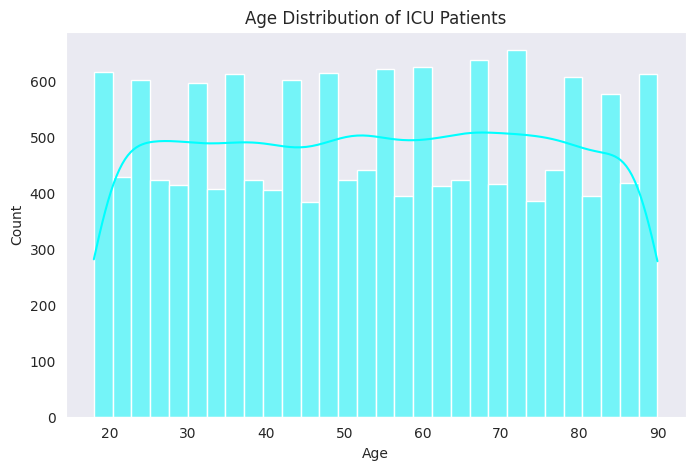

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"],
             bins=30,
             kde=True,
             color="cyan")

plt.title("Age Distribution of ICU Patients")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

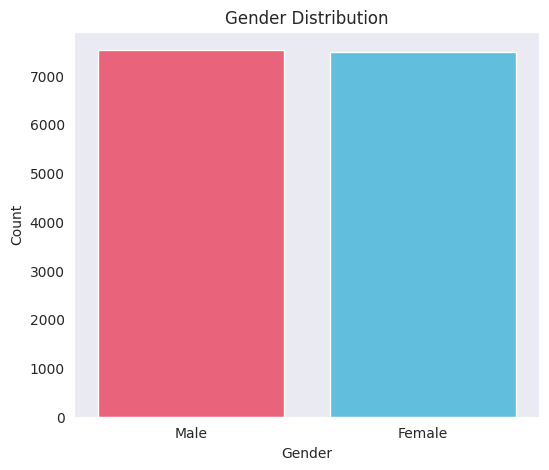

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(x="gender",
              data=df,
              palette=["#ff4d6d","#4cc9f0"])

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

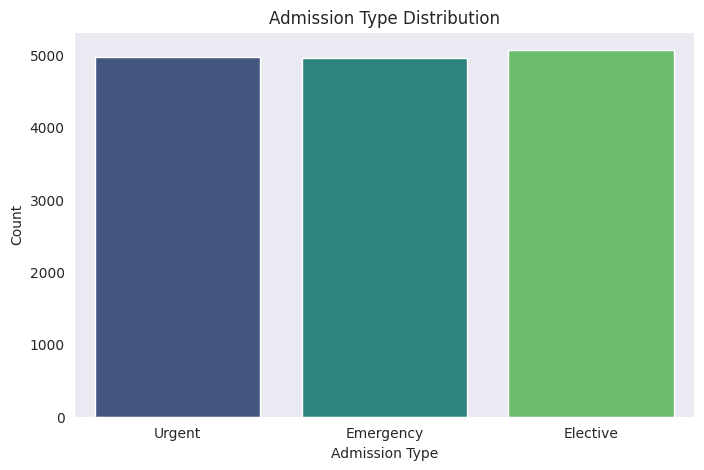

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x="admission_type",
              data=df,
              palette="viridis")

plt.title("Admission Type Distribution")
plt.xlabel("Admission Type")
plt.ylabel("Count")

plt.show()

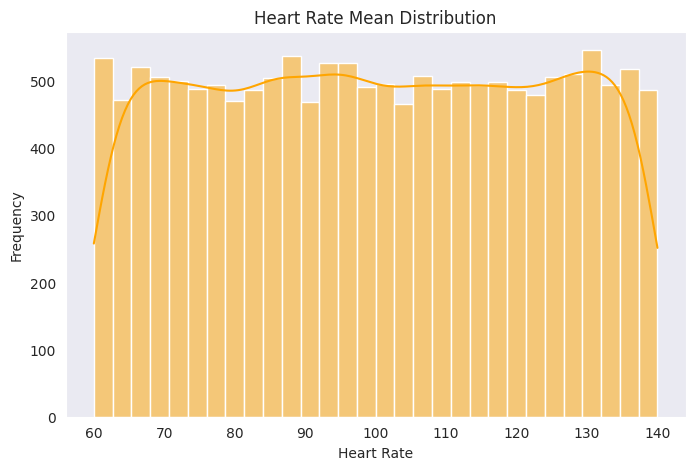

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["heart_rate_mean"],
             bins=30,
             color="orange",
             kde=True)

plt.title("Heart Rate Mean Distribution")
plt.xlabel("Heart Rate")
plt.ylabel("Frequency")

plt.show()

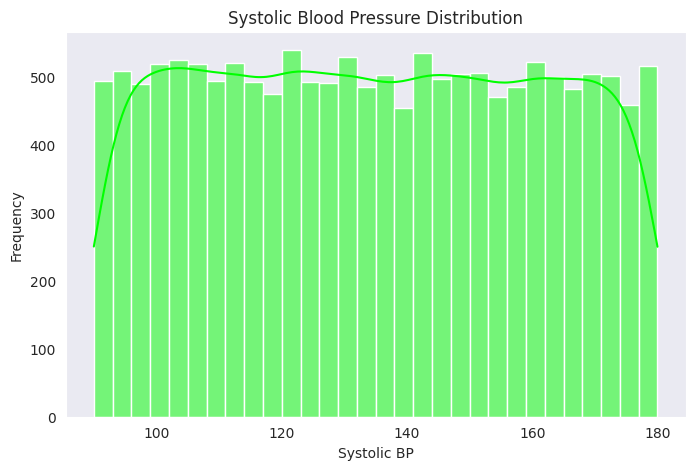

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["systolic_bp_mean"],
             bins=30,
             color="lime",
             kde=True)

plt.title("Systolic Blood Pressure Distribution")
plt.xlabel("Systolic BP")
plt.ylabel("Frequency")

plt.show()

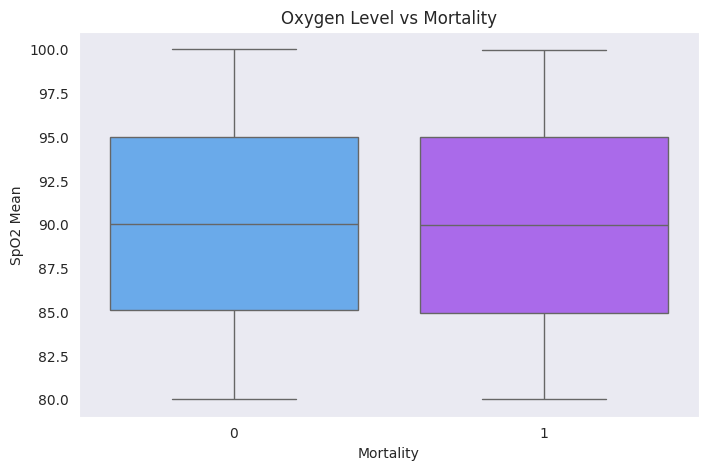

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x="mortality_label",
            y="spo2_mean",
            data=df,
            palette="cool")

plt.title("Oxygen Level vs Mortality")
plt.xlabel("Mortality")
plt.ylabel("SpO2 Mean")

plt.show()

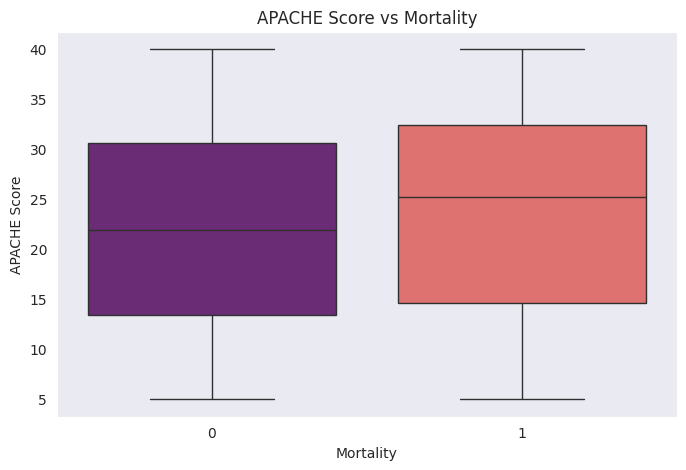

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x="mortality_label",
            y="apache_score",
            data=df,
            palette="magma")

plt.title("APACHE Score vs Mortality")
plt.xlabel("Mortality")
plt.ylabel("APACHE Score")

plt.show()

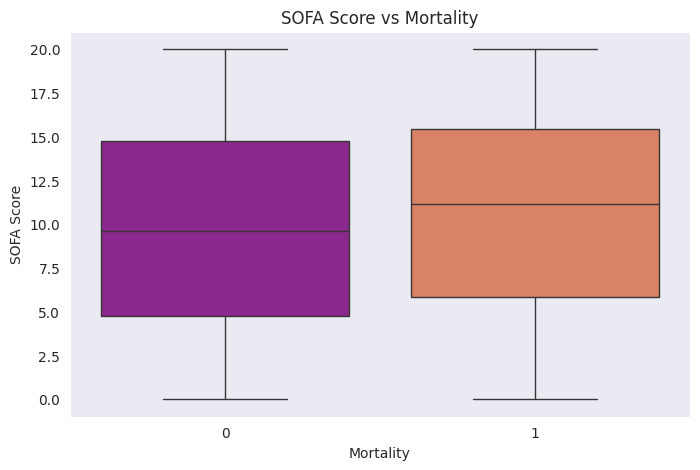

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x="mortality_label",
            y="sofa_score",
            data=df,
            palette="plasma")

plt.title("SOFA Score vs Mortality")
plt.xlabel("Mortality")
plt.ylabel("SOFA Score")

plt.show()


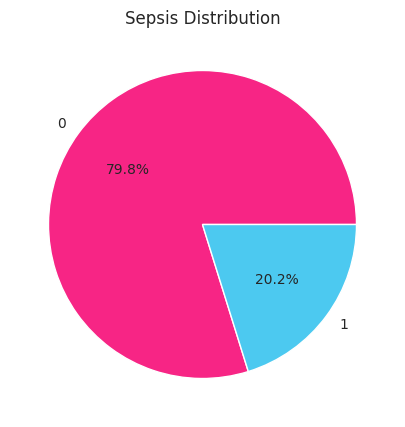

In [23]:
plt.figure(figsize=(6,5))

df["sepsis_flag"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#f72585","#4cc9f0"]
)

plt.title("Sepsis Distribution")

plt.ylabel("")

plt.show()

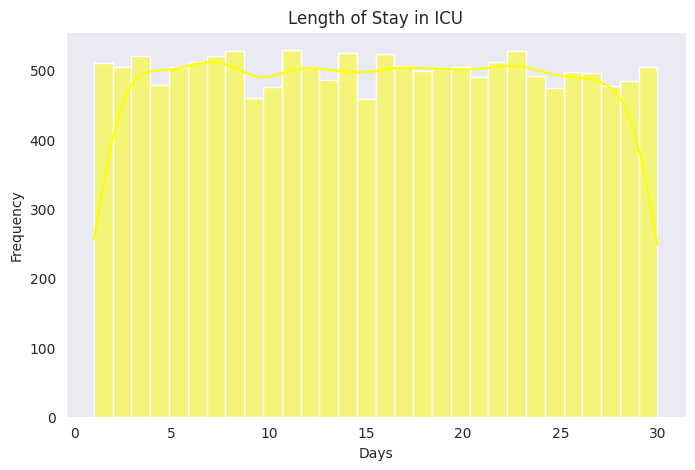

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["length_of_stay_days"],
             bins=30,
             color="yellow",
             kde=True)

plt.title("Length of Stay in ICU")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

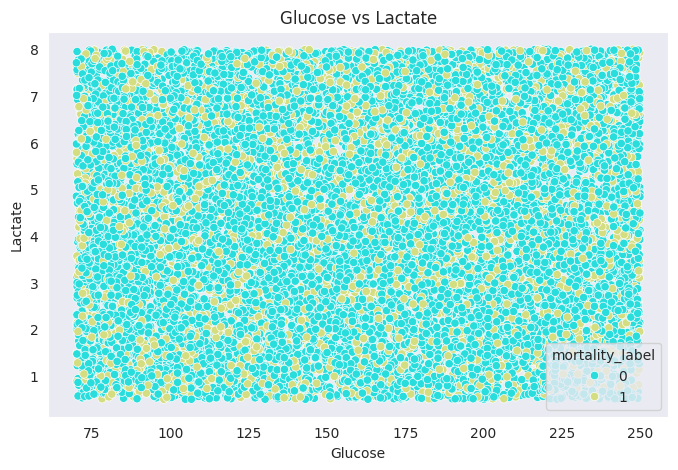

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="glucose_mean",
                y="lactate_mean",
                hue="mortality_label",
                palette="rainbow",
                data=df)

plt.title("Glucose vs Lactate")
plt.xlabel("Glucose")
plt.ylabel("Lactate")

plt.show()

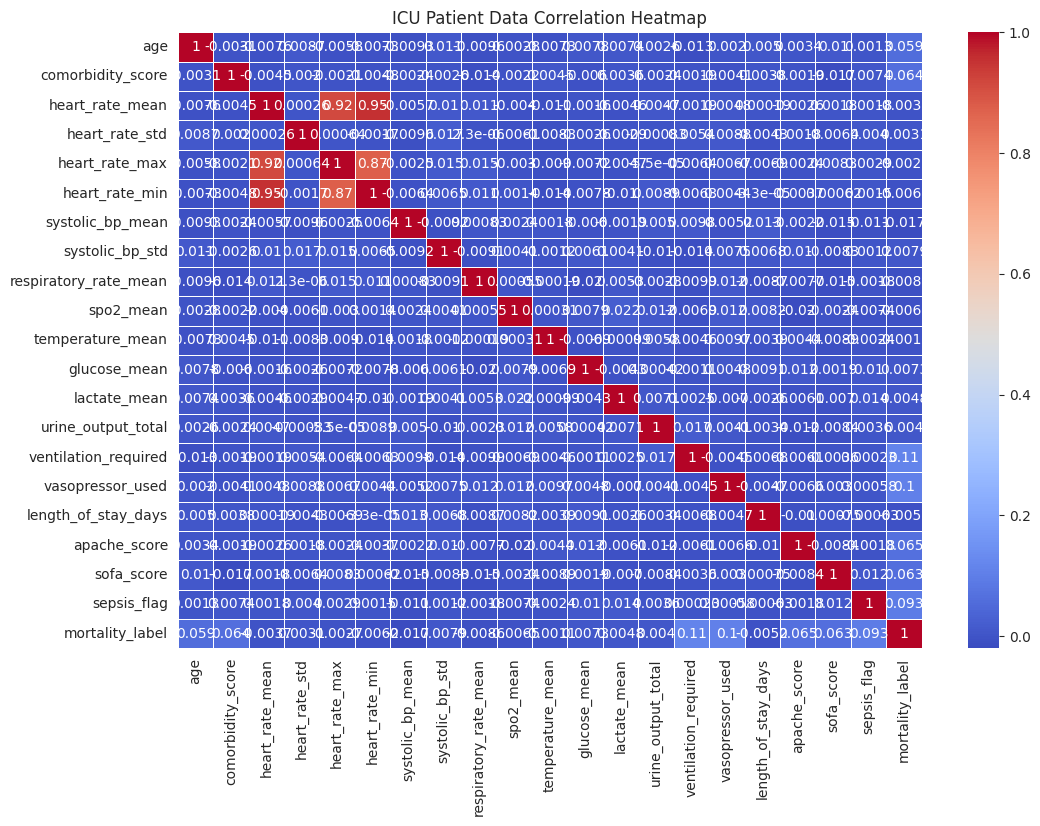

In [26]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap="coolwarm",
            annot=True,
            linewidths=0.5)

plt.title("ICU Patient Data Correlation Heatmap")

plt.show()

## Feature engineering

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [28]:
df = df.drop("patient_id", axis=1)

In [29]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [30]:
X = df.drop("mortality_label", axis=1)
y = df["mortality_label"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}

results = {}


In [34]:
classes = sorted(y.unique())
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)


In [35]:
for name, model in models.items():

    print("\n" + "="*60)
    print("MODEL:", name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc * 100

    print("Accuracy:", round(acc*100,2), "%")


MODEL: Logistic Regression
Accuracy: 76.9 %

MODEL: Decision Tree
Accuracy: 66.4 %

MODEL: Random Forest
Accuracy: 76.6 %

MODEL: KNN
Accuracy: 74.07 %

MODEL: Naive Bayes
Accuracy: 76.03 %


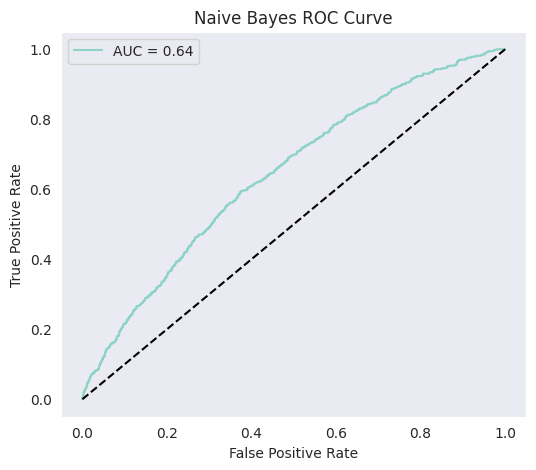

In [36]:
if hasattr(model, "predict_proba"):

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)

    plt.plot([0,1],[0,1],'k--')

    plt.title(name + " ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

In [37]:
print("\nFinal Accuracy Comparison")
print("="*40)

for model, acc in results.items():
    print(model, ":", round(acc,2), "%")


Final Accuracy Comparison
Logistic Regression : 76.9 %
Decision Tree : 66.4 %
Random Forest : 76.6 %
KNN : 74.07 %
Naive Bayes : 76.03 %


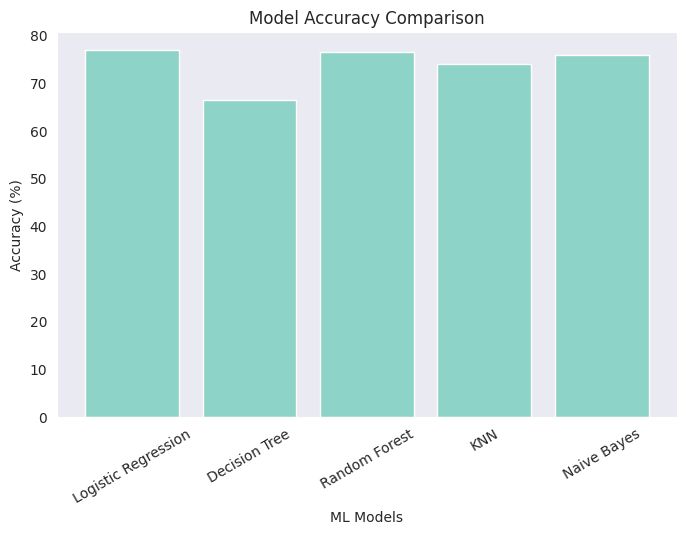

In [38]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")
plt.xlabel("ML Models")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)

plt.show()

## Thank you..pls upvote!!!!!!!!!!!